Dataset loaded: (15842, 13)
X shape: (15842, 4)
y shape: (15842,)

Baseline
MAE : 16.23908323190431
RMSE: 21.799393305541134
R2  : 0.03608180410485118

Random Forest
MAE : 16.17876299872509
RMSE: 21.815423767600738
R2  : 0.03466362376526311

XGBoost
MAE : 15.924304777607627
RMSE: 21.431014988150828
R2  : 0.0683842019456804


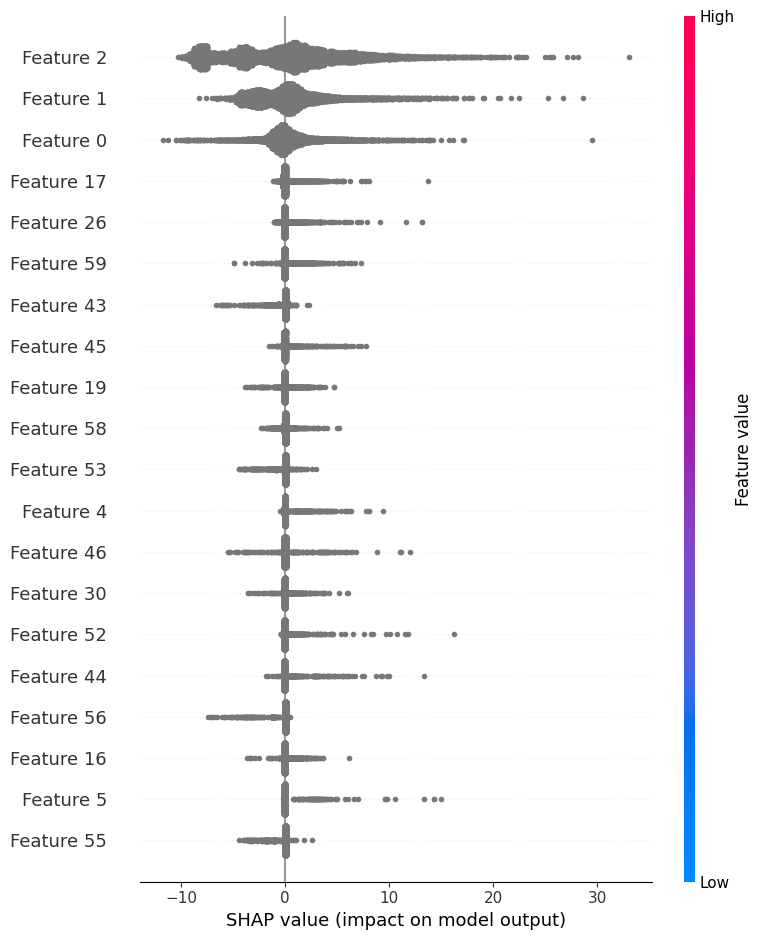

['feature_pipeline.pkl']

In [4]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline # Added Pipeline import

# Load feature-engineered dataset
df = pd.read_csv('/content/sample_data/dataset.csv')

print("Dataset loaded:", df.shape)
df.head()

# Input features
X = df[
    ['avg_runs_last_5', 'avg_runs_last_10', 'career_avg_runs', 'venue']
]

# Target variable
y = df['target_runs']

print("X shape:", X.shape)
print("y shape:", y.shape)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),
         ['avg_runs_last_5', 'avg_runs_last_10', 'career_avg_runs']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['venue'])
    ]
)



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
baseline_preds = X_test['avg_runs_last_10']

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
# Removed redundant import and train_test_split call here.


from xgboost import XGBRegressor

xgb_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)

def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2  :", r2_score(y_true, y_pred))

evaluate(y_test, baseline_preds, "Baseline")
evaluate(y_test, rf_preds, "Random Forest")
evaluate(y_test, xgb_preds, "XGBoost")

import shap

explainer = shap.Explainer(
    xgb_pipeline.named_steps['model']
)

X_transformed = preprocessor.fit_transform(X_train)
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed)

import joblib

joblib.dump(xgb_pipeline, 'xgb_model.joblib')
joblib.dump(preprocessor, 'feature_pipeline.pkl')
